# **Project Name-** Netflix Churn Analysis


 *  Project Type: EDA
 *  Contribution: Individual
 *  Member Name: Arjun Gawande


# **Project Summary -**

* In this dataset we have Neflix Churn Dataset, Netflix is a famous OTT platform across the Globe.
* This dataset consists of a cleaned customer activity data, along with a churn label specifying wheather a customer cancelled the subscription.
* This project focused on exploring Netflix churn data to uncover key factors influencing customer cancellations and to propose effective retention strategies.
* The analysis started with data quality checks and preprocessing, after which univariate, bivariate, and multivariate EDA was carried out to uncover meaningful patterns.
* We found that churn rates were particularly high in certain user segments, with nearly a quarter of users disengaging, and that the major drivers of churn were long gaps since last login, low content engagement, and limited platform usage.

# **Problem Statement**




The goal of this project is to analyze Netflix customer data to identify the key factors driving subscriber churn. By understanding user behavior and engagement patterns, we aim to generate insights and recommendations to improve customer retention and reduce cancellations.

### **Define Your Business Objective?**


The Business objective of this project is to reduce the churn rate of the customers

### **Hypothesis/Assumptions**

 


Before exploring and analysing the data we will take assumptions on the reason behind the churn.
* High number of customer support interactions indicates users are experiencing issues (e.g., streaming quality, billing, or app problems), which increases the likelihood of churn.

* High subscription cost relative to perceived value leads to churn when users feel the price is not justified by the content quality or variety.

In [92]:
import pandas as pd 
import numpy as np
import plotly.express as plx
import matplotlib.pyplot as plt 
import seaborn as sns 

In [93]:
netflix_df=pd.read_csv("netflix_customer_churn.csv")

In [94]:
netflix_df.shape

(5000, 14)

There are 5000 Rows and 14 columns 

In [95]:
netflix_df.columns.values

array(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre'], dtype=object)

### **Dataset Information**

* customer_id – Unique identifier for each Netflix customer
* age – Age of the subscriber
* gender – Gender of the customer (e.g., Male, Female, Other)
* subscription_type – Type of Netflix plan (e.g., Basic, Standard, Premium)
* watch_hours – Total number of hours the customer has spent watching content
* last_login_days – Number of days since the user last logged into Netflix
* region – Geographical region of the customer
* device – Primary device used to watch Netflix (e.g., Mobile, TV, Laptop, Tablet)
* monthly_fee – Monthly subscription amount paid by the customer
* churned – Yes/True indicates the customer has cancelled the subscription; No/False indicates the customer is still active
* payment_method – Method used for payment (e.g., Credit Card, Debit Card, UPI, Net Banking)
* number_of_profiles – Number of user profiles under the account
* avg_watch_time_per_day – Average number of hours watched per day by the customer
* favorite_genre – Most-watched content genre by the customer (e.g., Drama, Comedy, Action, Romance, Thriller)
* watch_group – Category based on total watch hours (e.g., Low, Medium, High engagement)
* login_gap_group – Category based on last login gap (e.g., Recently Active, Inactive, Dormant users)


### Data Cleaning And Preparation

In [96]:
netflix_df.isnull().sum()

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

There are no null values in Dataset

In [97]:
netflix_df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [98]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

* There are total 7 columns with object datatype which are classified into categorical columns 
* And rest 7 have numeric data type (float64,int64) which are classified into numerical columns 

In [99]:
netflix_df.dtypes

customer_id                object
age                         int64
gender                     object
subscription_type          object
watch_hours               float64
last_login_days             int64
region                     object
device                     object
monthly_fee               float64
churned                     int64
payment_method             object
number_of_profiles          int64
avg_watch_time_per_day    float64
favorite_genre             object
dtype: object

In [100]:
null_count=netflix_df.isnull().sum().reset_index().rename({"index":"column_names",0:"null_values"},axis=1)

In [101]:
null_count

,column_names,null_values
0,customer_id,0
1,age,0
2,gender,0
3,subscription_type,0
4,watch_hours,0
5,last_login_days,0
6,region,0
7,device,0
8,monthly_fee,0
9,churned,0


C:\Users\Arjun\AppData\Local\Temp\ipykernel_21536\2535734133.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



[Text(0, 0, 'customer_id'),
 Text(1, 0, 'age'),
 Text(2, 0, 'gender'),
 Text(3, 0, 'subscription_type'),
 Text(4, 0, 'watch_hours'),
 Text(5, 0, 'last_login_days'),
 Text(6, 0, 'region'),
 Text(7, 0, 'device'),
 Text(8, 0, 'monthly_fee'),
 Text(9, 0, 'churned'),
 Text(10, 0, 'payment_method'),
 Text(11, 0, 'number_of_profiles'),
 Text(12, 0, 'avg_watch_time_per_day'),
 Text(13, 0, 'favorite_genre')]

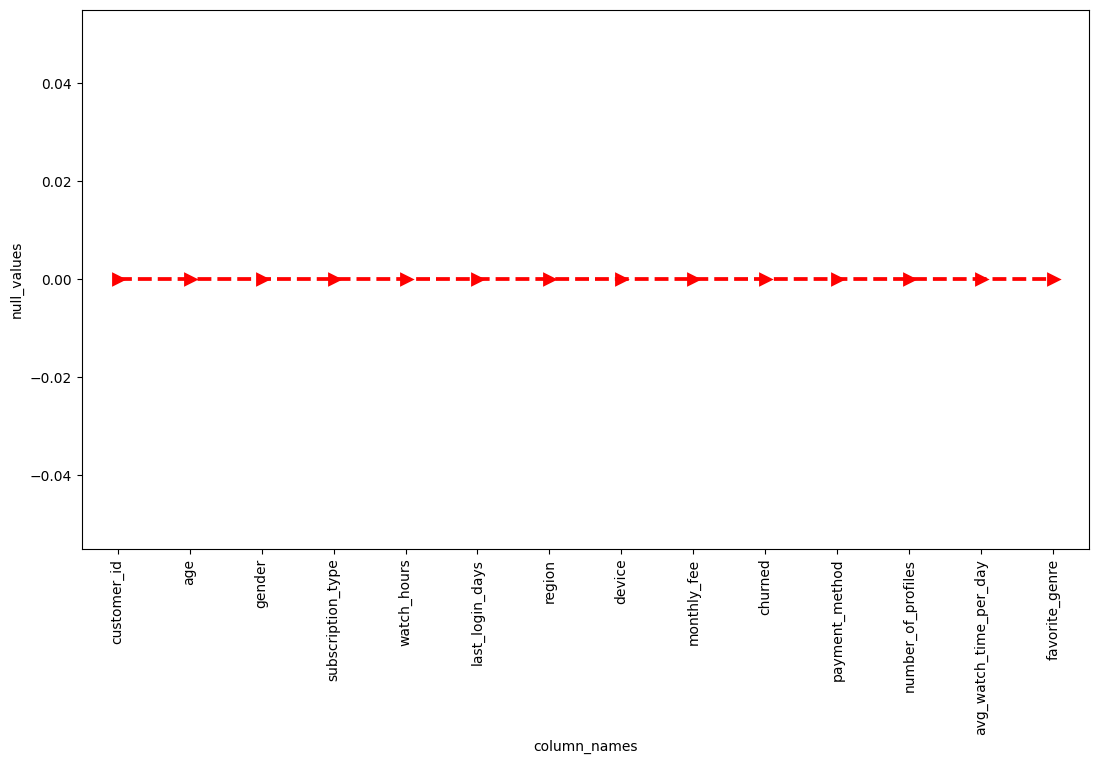

In [112]:
fig, ax = plt.subplots(figsize=(13, 7))
title="null value in the datset"
sns.pointplot(x=null_count["column_names"],y=null_count["null_values"],linestyles = '--', color = "red", markers= '>',ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

In [103]:
netflix_df.duplicated().sum()

np.int64(0)

There are no duplicate column in dataset

In [104]:
numerical_featuress=netflix_df.describe().drop(columns=['age','watch_hours','last_login_days','monthly_fee','number_of_profiles','avg_watch_time_per_day']).columns.values

In [105]:
categorical_features=netflix_df.drop(columns=['age','watch_hours','last_login_days','monthly_fee','number_of_profiles','avg_watch_time_per_day',"customer_id"]).columns

In [106]:
numerical_featuress=netflix_df.drop(columns=['customer_id','gender','subscription_type','region','device','churned','payment_method','favorite_genre'])

In [107]:
categorical_features


Index(['gender', 'subscription_type', 'region', 'device', 'churned',
       'payment_method', 'favorite_genre'],
      dtype='object')

In [15]:
numerical_featuress

,age,watch_hours,last_login_days,monthly_fee,number_of_profiles,avg_watch_time_per_day
0,51,14.73,29,8.99,1,0.49
1,47,0.70,19,13.99,5,0.03
2,27,16.32,10,13.99,2,1.48
3,53,4.51,12,17.99,2,0.35
4,56,1.89,13,13.99,2,0.13
...,...,...,...,...,...,...
4995,19,49.17,11,8.99,4,4.10
4996,67,9.24,2,8.99,3,3.08
4997,66,16.55,49,13.99,2,0.33
4998,59,9.12,3,8.99,4,2.28


In [108]:
netflix_df["churned"].value_counts()

churned
1    2515
0    2485
Name: count, dtype: int64

The rate  of Churned customer is  very high, which is approximately 50%

In [109]:
netflix_df.dtypes

customer_id                object
age                         int64
gender                     object
subscription_type          object
watch_hours               float64
last_login_days             int64
region                     object
device                     object
monthly_fee               float64
churned                     int64
payment_method             object
number_of_profiles          int64
avg_watch_time_per_day    float64
favorite_genre             object
dtype: object

### Univariate analysis

**Univariate analysis for Numerical_features**

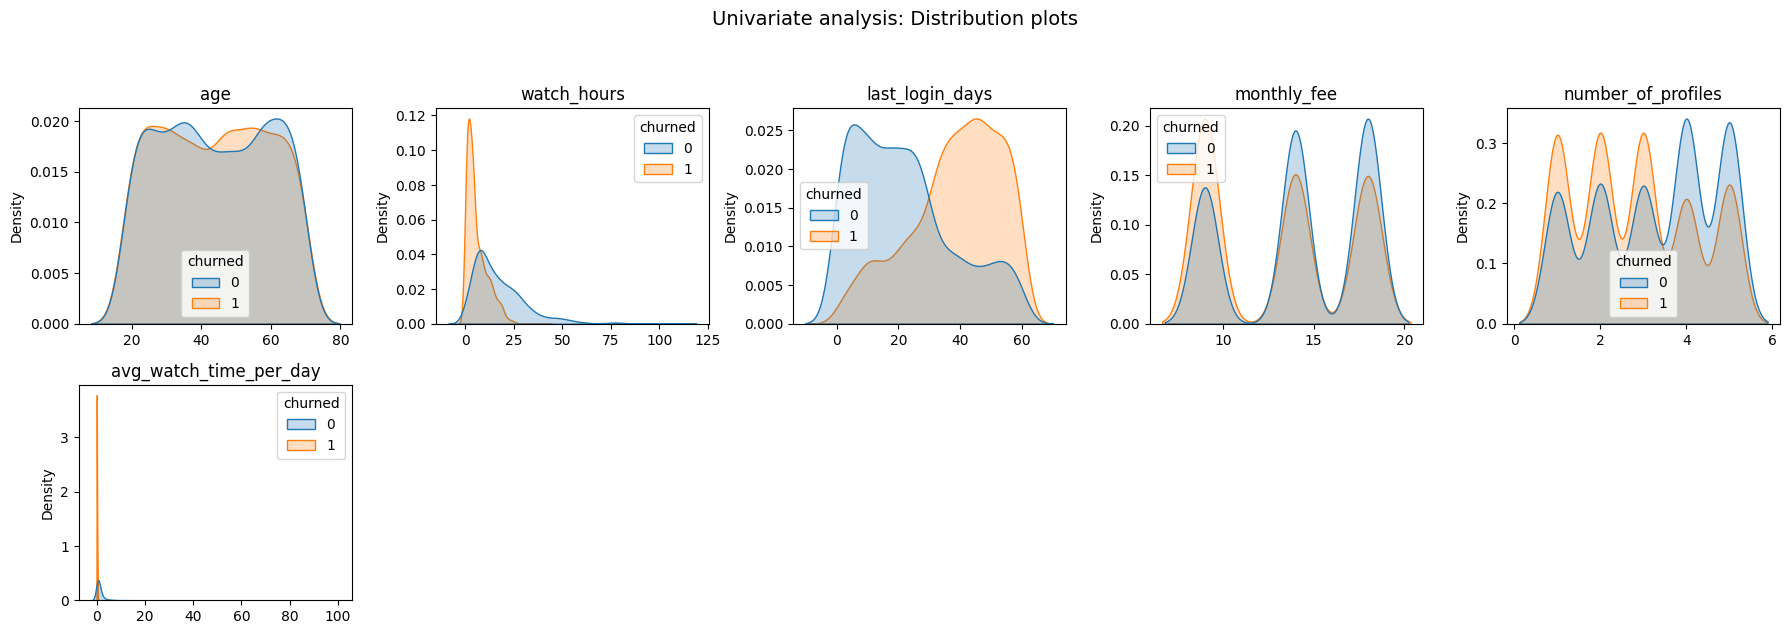

In [18]:
plt.figure(figsize=(18, 9))
plt.suptitle('Univariate analysis: Distribution plots', fontsize=14)
i=0
for i, col in enumerate(numerical_featuress):
    plt.subplot(3, 5, i + 1)
    sns.kdeplot(
        data=netflix_df,
        x=col,
        hue='churned',
        fill=True,
        common_norm=False
    )
    plt.title(col)
    plt.xlabel('')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

From the above graph we get the following information 
1. Age
The age distribution of churned and non-churned users is quite similar, indicating that age alone is not a strong predictor of churn. However, slight variations suggest that mid-age groups may show marginally higher churn behavior.

2. Watch Hours
Customers who churn tend to have very low total watch hours. Active users (non-churned) show a wider and higher distribution of watch hours, meaning higher engagement strongly reduces churn risk.

3. Last Login Days
Churned users have significantly higher last_login_days, showing they haven’t logged in for a long time. This clearly indicates that inactivity is a strong signal of churn.

4. Monthly Fee
The churn distribution slightly peaks around certain price points, suggesting that users on higher-priced plans may be more sensitive to cost and more likely to churn if they don’t perceive enough value.

5. Number of Profiles
Non-churned users tend to have more profiles per account, which suggests family/shared accounts are more stable and less likely to cancel.

6. Avg Watch Time Per Day
Churned users show very low daily watch time, while retained users spend more time watching per day. This confirms that daily engagement is a key retention driver.

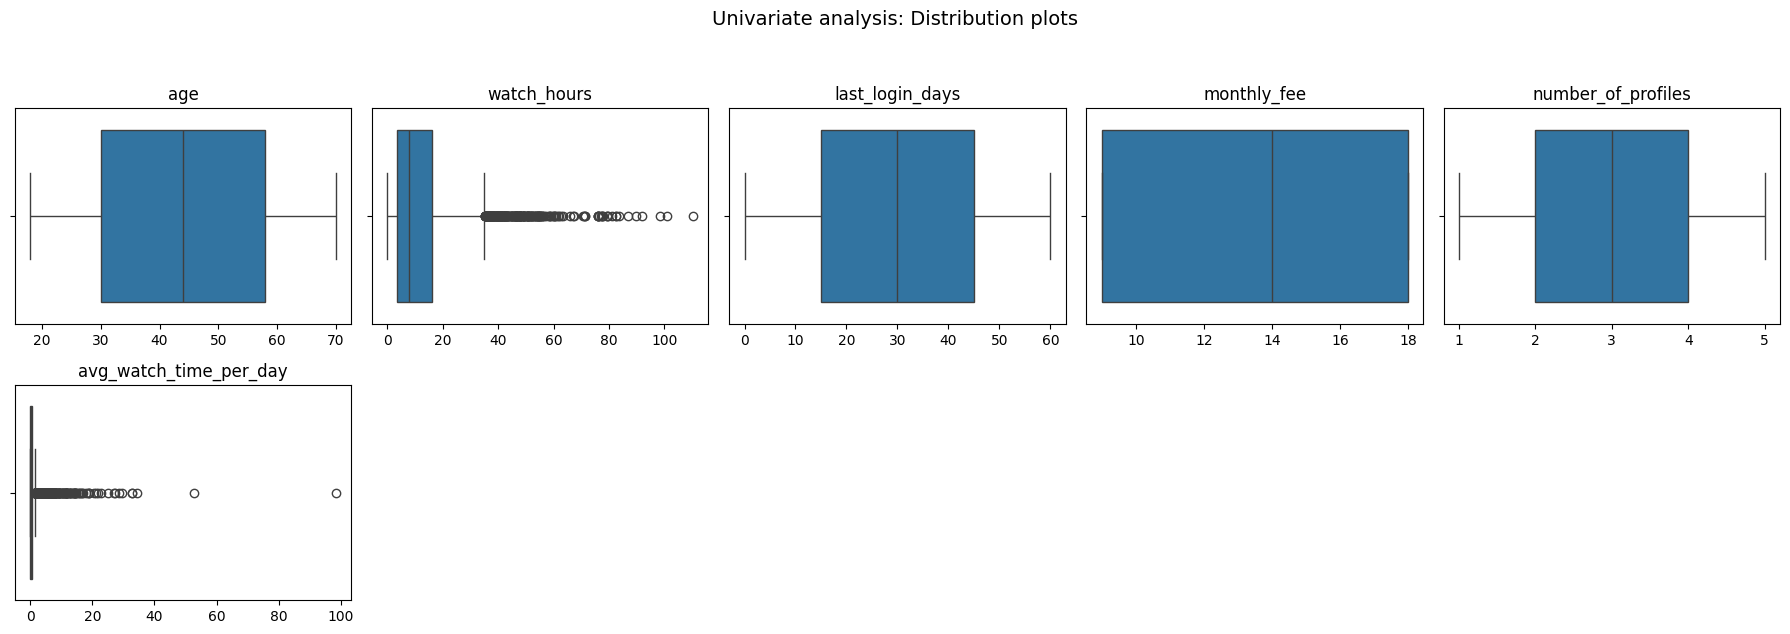

In [110]:
plt.figure(figsize=(18, 9))
plt.suptitle('Univariate analysis: Distribution plots', fontsize=14)
i=0
for i, col in enumerate(numerical_featuress):
    plt.subplot(3, 5, i + 1)
    sns.boxplot(
        data=netflix_df,
        x=col,
        
       
    )
    plt.title(col)
    plt.xlabel('')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Univariate analysis for categorical_features**

In [ ]:
categorical_features

Index(['gender', 'subscription_type', 'region', 'device', 'churned',
       'payment_method', 'favorite_genre'],
      dtype='object')

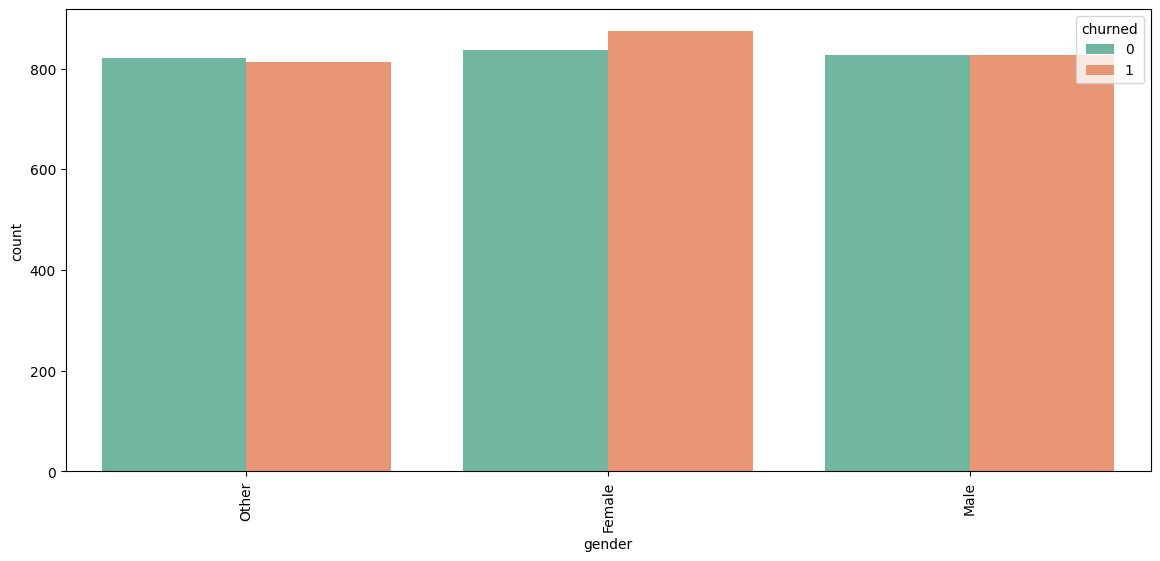

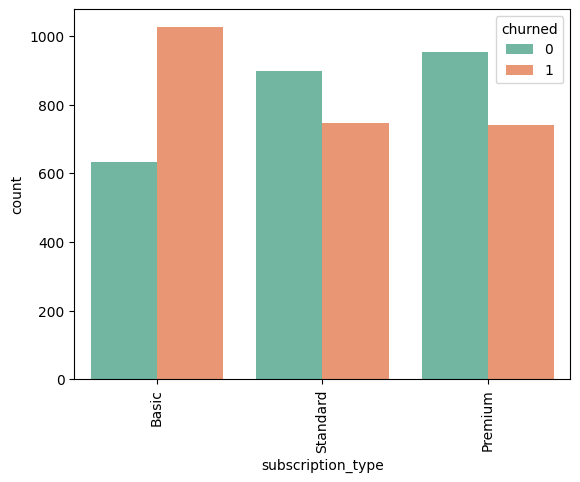

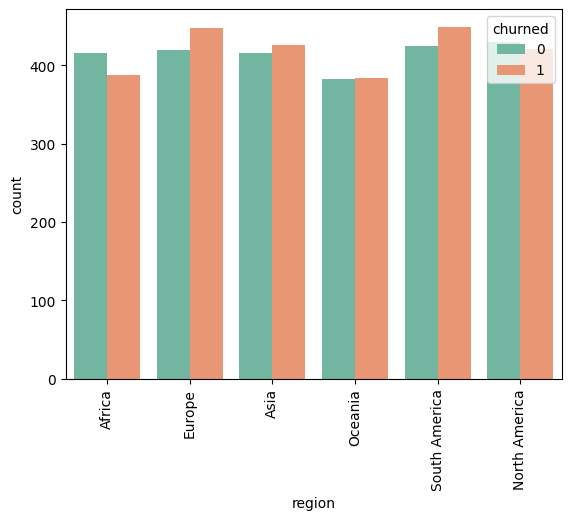

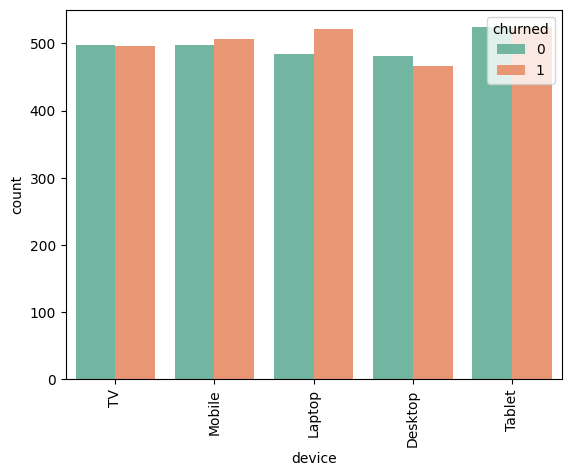

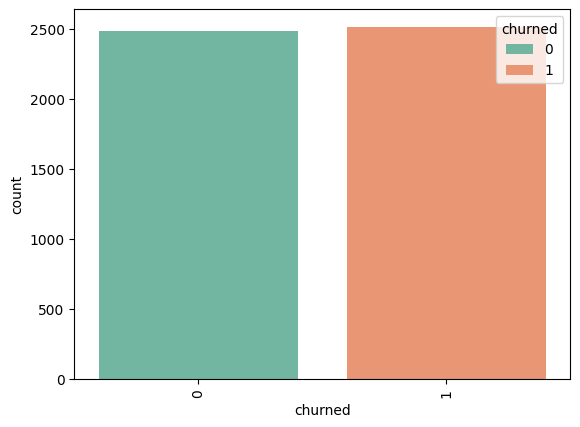

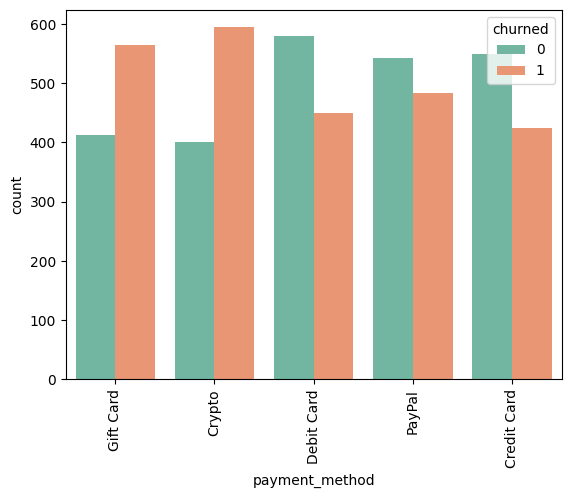

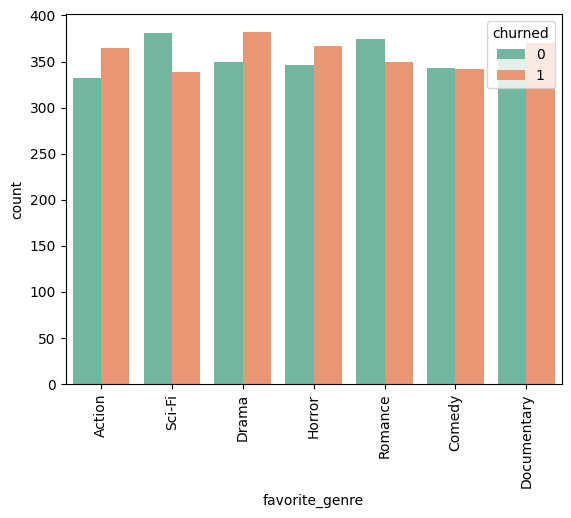

In [111]:

plt.figure(figsize=(14,6))
for i in range(0, len(categorical_features)): 
  title='Univariate analysis: categorical_features'
  ax = sns.countplot(x=categorical_features[i], data=netflix_df, hue="churned",  palette="Set2")
  plt.xlabel(categorical_features[i])
  plt.xticks(rotation=90)
  plt.show()

* From the above graph we obsewrved that the  basic subscription_type showing a higher churn rate
* The graph showing churned by payement method showing higher churniong rate for methods like "gift card" and  "crypto"

**BIVARITATE ANALYSIS**

In [63]:
netflix_df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [ ]:
df_rate = netflix_df.groupby("subscription_type")["churned"].mean().reset_index()

fig = plx.bar(
    df_rate,
    x="subscription_type",
    y="churned",
    color="subscription_type",
    title="Churn Rate by Subscription Type"
)
fig.update_yaxes(tickformat=".0%")
fig.show()


In [35]:
df_rates = netflix_df.groupby("payment_method")["churned"].mean().reset_index()

fig = plx.bar(
    df_rates,
    x="churned",
    y="payment_method",
    color="payment_method",
    barmode="stack",
    title="Churn % by Payment Method"
)
fig.update_xaxes(tickformat=".0%")
fig.show()

In [73]:
netflix_df["watch_group"] = pd.cut(
    netflix_df["watch_hours"],
    bins=[0,2,5,10,20,40,100],
    labels=["0–2","2–5","5–10","10–20","20–40","40+"]
)

df_watch = netflix_df.groupby("watch_group")["churned"].mean().reset_index()

fig = plx.line(
    df_watch,
    x="watch_group",
    y="churned",
    markers=True,
  
    title="Churn Rate by Watch Hours Group",
    


)
fig.update_traces(fill="tozeroy", fillcolor="rgba(255, 193, 7, 0.3)",line=dict(color='orange', width=3))

fig.update_yaxes(tickformat=".0%")
fig.show()

C:\Users\Arjun\AppData\Local\Temp\ipykernel_21536\506246343.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [72]:
fig = plx.box(
    netflix_df,
    x="churned",
    y="last_login_days",
    color="churned",
    title="Last Login Days Distribution by Churn Status"
)
fig.show()

**multivaritate analysis**

In [74]:
netflix_df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,watch_group,login_gap_group
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,10–20,22–30
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,0–2,15–21
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama,10–20,8–14
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror,2–5,8–14
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,0–2,8–14


In [77]:
numeric_cols = netflix_df.select_dtypes(include='number').columns
print(numeric_cols)


Index(['age', 'watch_hours', 'last_login_days', 'monthly_fee', 'churned',
       'number_of_profiles', 'avg_watch_time_per_day'],
      dtype='object')


In [78]:
# Correlation
corr_matrix = netflix_df[numeric_cols].corr()
print("Correlation Matrix:")
print(corr_matrix)

# Covariance
cov_matrix = netflix_df[numeric_cols].cov()
print("Covariance Matrix:")
print(cov_matrix)


Correlation Matrix:
                             age  watch_hours  last_login_days  monthly_fee  \
age                     1.000000     0.031539         0.016769    -0.013943   
watch_hours             0.031539     1.000000         0.001697     0.004960   
last_login_days         0.016769     0.001697         1.000000    -0.000789   
monthly_fee            -0.013943     0.004960        -0.000789     1.000000   
churned                -0.003515    -0.479916         0.471590    -0.152117   
number_of_profiles      0.017333     0.016528         0.017242     0.021905   
avg_watch_time_per_day  0.010355     0.349742        -0.338418    -0.010401   

                         churned  number_of_profiles  avg_watch_time_per_day  
age                    -0.003515            0.017333                0.010355  
watch_hours            -0.479916            0.016528                0.349742  
last_login_days         0.471590            0.017242               -0.338418  
monthly_fee            -0.15211

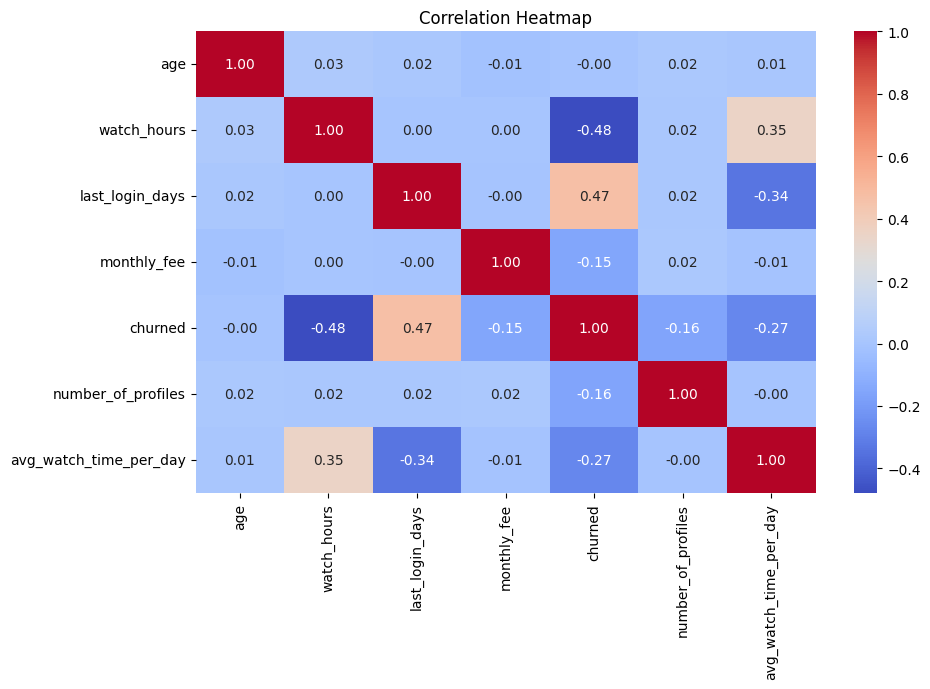

In [79]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# **Final conclusuion** 
* Low watch hours and low avg watch time per day strongly increase churn risk  
* High last_login_days (long inactivity) is one of the strongest indicators of churn  
* Customers paying a higher monthly fee with low usage are more likely to churn  
* Accounts with fewer profiles show higher churn than shared/family accounts  
* Certain regions have noticeably higher churn rates than others  
* Overall churn is driven by low engagement, inactivity, and low perceived value  


# **Recommendations**
* Re-engage inactive users with personalized notifications and content suggestions  
* Offer value-based pricing or flexible plans for low-usage high-fee customers  
* Encourage users to create multiple profiles for family/shared viewing  
* Improve content discovery to boost daily watch time and engagement  
* Launch region-specific campaigns where churn rates are high  
* Use early-warning signals (low usage + high login gap) to trigger retention offers  
